## 1. Imports

In [2]:
# import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor

import joblib
import os

warnings.filterwarnings('ignore')

## 2. Load Data

In [3]:
# Notebook 2 (Training): Load
df_final = pd.read_parquet('../data/tehranhouses_preprocessed.parquet')
df_final.head()

,Area,Room,Parking,Warehouse,Elevator,Price(USD),Address_Abbasabad,Address_Absard,Address_Abuzar,Address_Afsarieh,...,Address_Waterfall,Address_West Ferdows Boulevard,Address_West Pars,Address_Yaftabad,Address_Yakhchiabad,Address_Yousef Abad,Address_Zafar,Address_Zaferanieh,Address_Zargandeh,Address_Zibadasht
0,63,1,1,1,1,61666.67,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,60,1,1,1,1,61666.67,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,79,2,1,1,1,18333.33,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,95,2,1,1,1,30083.33,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,123,2,1,1,1,233333.33,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [4]:
# Feature / Target Split
X = df_final.drop('Price(USD)', axis=1)
y = df_final['Price(USD)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (2752, 196)  |  Test: (688, 196)


In [ ]:
# Model Comparison (replacing PyCaret's setup + compare_models)
models = {
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1, n_estimators=300),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False, iterations=600),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0, n_estimators=300),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=300),
    'Extra Trees': ExtraTreesRegressor(random_state=42, n_jobs=-1, n_estimators=300),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=300)
}

results = []

for name, mdl in models.items():
    # 5-fold cross-validated R2 on the training set
    cv_scores = cross_val_score(mdl, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)

    # Fit on the full training set and evaluate on the held-out test set
    mdl.fit(X_train, y_train)
    preds = mdl.predict(X_test)

    results.append({
        'Model': name,
        'CV R2 (mean)': cv_scores.mean(),
        'CV R2 (std)': cv_scores.std(),
        'Test R2': r2_score(y_test, preds),
        'Test MAE': mean_absolute_error(y_test, preds),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, preds))
    })

comparison_df = pd.DataFrame(results).sort_values('CV R2 (mean)', ascending=False).reset_index(drop=True)
comparison_df

,Model,CV R2 (mean),CV R2 (std),Test R2,Test MAE,Test RMSE
0,CatBoost,0.821936,0.043387,0.589693,51416.821332,167253.286091
1,Extra Trees,0.807314,0.056666,0.604193,49006.318593,164271.472309
2,Gradient Boosting,0.787565,0.061767,0.576408,56783.279327,169939.555310
3,Random Forest,0.770809,0.055623,0.611597,52052.557724,162727.845205
4,XGBoost,0.760663,0.045817,0.620472,47877.966678,160857.884590
5,LightGBM,0.756799,0.048727,0.649698,57654.415147,154540.322008


In [6]:
# Keep the best-performing fitted model (mirrors PyCaret's `best_model`)
best_model_name = comparison_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\nBest model by CV R2: {best_model_name}")


Best model by CV R2: CatBoost


In [7]:
# # Define the parameter grid for tuning
# param_grid = {
#     'n_estimators': [600],
#     'learning_rate': [0.03],
#     'min_samples_leaf': [1],
#     # 'subsample': [0.4, 0.5, 0.6, 0.7],
#     # 'max_depth': [9, 11],
# }

# # Set up the GridSearchCV
# grid_search = GridSearchCV(
#     estimator=GradientBoostingRegressor(random_state=42),
#     param_grid=param_grid,
#     cv=5,              # 5-fold cross-validation
#     scoring='r2',
#     n_jobs=-1          # Use all available CPU cores
# )

# # Run the grid search
# grid_search.fit(X_train, y_train)

In [8]:
# # Define the parameter grid for tuning
# param_grid = {
#     'iterations': [800],
#     'learning_rate': [0.075],
#     'depth': [13],
# }

# # Set up the GridSearchCV with CatBoostRegressor
# grid_search = GridSearchCV(
#     estimator=CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False),
#     param_grid=param_grid,
#     cv=5,              # 5-fold cross-validation
#     scoring='r2',
#     n_jobs=-1          # Use all available CPU cores
# )

# # Run the grid search
# grid_search.fit(
#     X_train, 
#     y_train, 
#     allow_writing_files=False
# )

In [9]:
param_grid = {
    'n_estimators': [600],
    'learning_rate': [0.05],
    'num_leaves': [31],
    'max_depth': [-1],
}

grid_search = GridSearchCV(
    estimator=LGBMRegressor(random_state=42, verbose=-1),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LGBMRegressor(random_state=42, verbose=-1),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05], 'max_depth': [-1],
                         'n_estimators': [600], 'num_leaves': [31]},
             scoring='r2')

In [10]:
# Print out the best parameters and cross-validation score
print("Best hyperparameters found:")
print(grid_search.best_params_)
print("\nBest cross-validation accuracy: {:.2f}".format(grid_search.best_score_ ))

model = grid_search.best_estimator_

# Predict & Evaluate
print(f"\nModel Performance On Test set:")

predictions = model.predict(X_test)

r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"        R^2 Score: {r2:.4f}")
print(f"        MSE: {mse:.4f}")
print("        RMSE: %f" % (rmse))

Best hyperparameters found:
{'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 600, 'num_leaves': 31}

Best cross-validation accuracy: 0.76

Model Performance On Test set:
        R^2 Score: 0.6509
        MSE: 23803017451.6429
        RMSE: 154282.265512


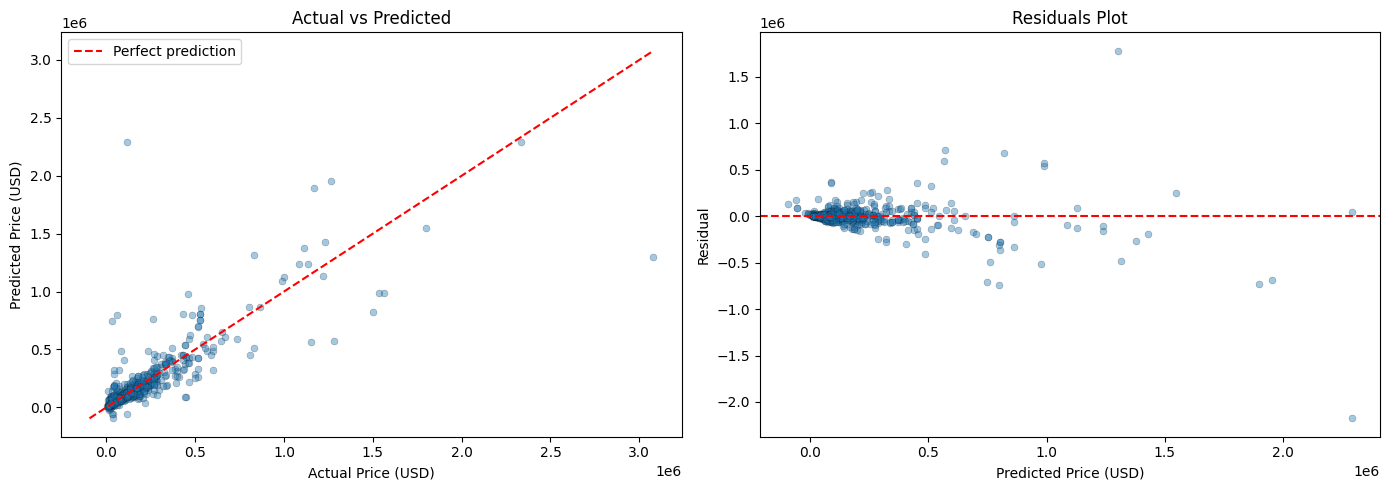

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
y_pred_best = model.predict(X_test)

# Scatter: Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, y_pred_best, alpha=0.4, edgecolors='k', linewidths=0.3, s=25)
lim = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (USD)'); ax.set_ylabel('Predicted Price (USD)')
ax.set_title(f'Actual vs Predicted'); ax.legend()

# Residuals
ax = axes[1]
residuals = y_test.values - y_pred_best
ax.scatter(y_pred_best, residuals, alpha=0.4, edgecolors='k', linewidths=0.3, s=25)
ax.axhline(0, color='r', linestyle='--', lw=1.5)
ax.set_xlabel('Predicted Price (USD)'); ax.set_ylabel('Residual')
ax.set_title('Residuals Plot')

plt.tight_layout(); plt.show()

### Feature Importances

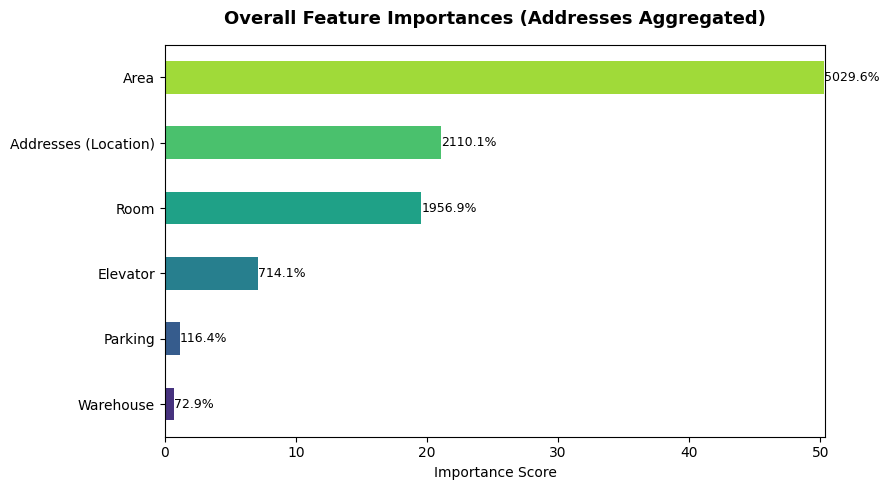

In [12]:
# Feature Importances
if hasattr(model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=X_train.columns)
    
    # Extract and sum up all one-hot encoded 'Address_' column scores
    address_mask = imp.index.str.startswith('Address_')
    total_address_importance = imp[address_mask].sum()
    
    # Build a new series grouping all other numerical features + the unified Address score
    grouped_imp = imp[~address_mask].copy()
    grouped_imp['Addresses (Location)'] = total_address_importance
    
    # Sort them for the plot
    grouped_imp = grouped_imp.sort_values(ascending=True)

    # Plot the unified feature importances
    plt.figure(figsize=(9, 5))
    grouped_imp.plot.barh(color=sns.color_palette('viridis', len(grouped_imp)))
    
    # Add data labels inside/next to the bars
    for i, val in enumerate(grouped_imp.values):
        plt.text(val + 0.005, i, f"{val*100:.1f}%", va='center', fontsize=9, fontweight='medium')
        
    plt.title('Overall Feature Importances (Addresses Aggregated)', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Importance Score')
    plt.xlim(0, max(grouped_imp.values) + 0.08)  # Leave room for text labels
    plt.tight_layout()
    plt.show()
else:
    print("The best model does not expose feature_importances_.")

## Save Trained Model

In [14]:
# Save Trained Model
os.makedirs('saved_models', exist_ok=True)

model_filename = 'saved_models/tehran_housing_best_model.pkl'
features_filename = 'saved_models/model_features.pkl'

# Save the best model and the specific column layout
joblib.dump(model, model_filename, compress=3)
# joblib.dump(model, model_filename)
joblib.dump(X_train.columns.tolist(), features_filename)

['saved_models/model_features.pkl']